In [1]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3001
1190


In [2]:
X = dat["V_offset"][mask].flatten()
arg = np.argsort(X)
X = X[arg]
Y = dat["U_i"][mask].flatten()
Y = Y[arg]

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable


class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.a = nn.Parameter(torch.randn(()))  # Initialize the 'a' parameter
        self.b = nn.Parameter(torch.randn(()))  # Initialize the 'b' parameter

    def forward(self, x):
        return self.a * x + self.b


# Convert data to torch tensors
X_torch = torch.tensor(X, dtype=torch.float32)
Y_torch = torch.tensor(Y, dtype=torch.float32)

# Initialize the model
model = LinearModel()

# Loss Function and Optimizer
criterion = nn.MSELoss()
# optimizer = optim.SGD(model.parameters(), lr=0.01)
# Using L-BFGS Optimizer
maxiter = 1000
tol = 1e-9
optimizer = optim.LBFGS(
    model.parameters(),
    lr=0.005,
    max_iter=maxiter,
    tolerance_grad=tol * 1e2,
    tolerance_change=tol,
)

# Training Loop
loss_old = torch.inf
loss_new = torch.inf


def closure():
    optimizer.zero_grad()
    outputs = model(X_torch)
    loss = criterion(outputs, Y_torch)
    loss.backward()
    return loss


# Training Loop
for epoch in range(maxiter):  # Number of epochs
    if loss_old - loss_new < tol:
        break
    loss_old = loss_new

    optimizer.step(closure)
    loss = closure().item()
    loss_new = loss
    # # Forward pass
    # outputs = model(X_torch)
    # loss = criterion(outputs, Y_torch)
    # loss_new = loss.item()
    if epoch % 1 == 0:
        print(f"Epoch [{epoch+1}/{maxiter}], Loss: {loss_new:.4f}")
    # # Backward and optimize
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()


def r_squared(X, Y, model):
    # Step 1: Predict Outputs
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predictions = model(X)

    # Step 2: Calculate SST
    sst = torch.std(Y) ** 2
    # Step 3: Calculate SSR
    ssr = torch.mean((Y - predictions) ** 2)

    # Step 4: Compute R^2
    r2 = 1 - ssr / sst
    return r2.item()


r2 = r_squared(X_torch, Y_torch, model)
a = model.a.item()
b = model.b.item()

print(f"Exponential model: Y = {b} + {a} * X")
print(f"Final Loss: {loss_new:.4f}")
print(f"R^2 Score: {r2}")

Epoch [1/1000], Loss: 0.0047
Epoch [2/1000], Loss: 0.0035
Epoch [3/1000], Loss: 0.0035
Epoch [4/1000], Loss: 0.0035
Epoch [5/1000], Loss: 0.0035
Epoch [6/1000], Loss: 0.0035
Epoch [7/1000], Loss: 0.0035
Epoch [8/1000], Loss: 0.0035
Epoch [9/1000], Loss: 0.0035
Exponential model: Y = -1.3106005191802979 + 2.4387383460998535 * X
Final Loss: 0.0035
R^2 Score: 0.21538293361663818


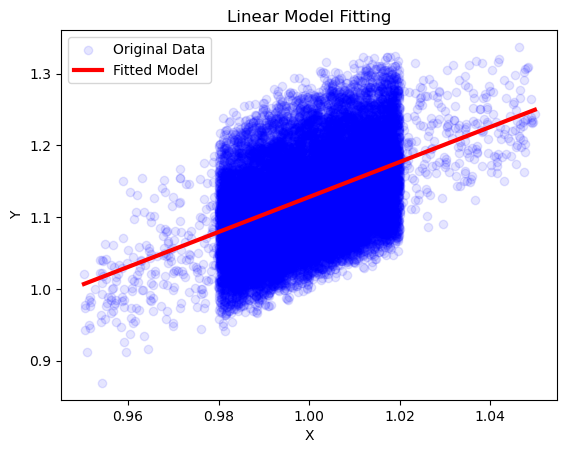

In [11]:
import matplotlib.pyplot as plt

# Generate predictions from the model
with torch.no_grad():  # We don't need gradients for prediction
    predicted = model(X_torch).numpy()

# Plotting the original data
plt.scatter(X, Y, color="blue", label="Original Data", alpha=0.1)

# Plotting the model's predictions
plt.plot(X, predicted, color="red", label="Fitted Model", linewidth=3)

# Adding labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Model Fitting")
plt.legend()